### Analysis: Identifying a relationship between wealth inequality and declines in American manufacturing

For the sake of completeness, I've attached all of my findings to the main presentation via an html link. Not all of the analyses I ran found significant results

In [2]:
# Relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import datetime as dt
import statsmodels as sm

# Stationarity testing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
import ruptures as rpt

# Granger causality
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR

# Cointegration testing
from statsmodels.tsa.stattools import coint

# Importing data
laborforce = pd.read_csv("data/laborforce.csv") 
totaljobs =  pd.read_csv("data/manufacturing_jobs.csv")
wages_manufacturing = pd.read_csv("data/manufacturing_wages.csv")
wages_all_sectors = pd.read_csv("data/wages_all_sectors.csv")
cpi = pd.read_csv("data/consumerpriceindex.csv")
gini = pd.read_csv("data/ginicoefficient.csv")

### Cleaning and joining data

In [3]:
# Cleaning data
# Wages (manufacturing and all private sector)
adjusted_wages = pd.merge(wages_manufacturing, cpi, on="observation_date", how="inner")
adjusted_wages = pd.merge(adjusted_wages, wages_all_sectors, on="observation_date", how="inner")
adjusted_wages["real_wages_manufacturing"] = (adjusted_wages["CES3000000008"]/adjusted_wages["CPIAUCSL"])*100
adjusted_wages["real_wages_all"] = (adjusted_wages["AHETPI"]/adjusted_wages["CPIAUCSL"])*100
adjusted_wages["observation_date"] = pd.to_datetime(adjusted_wages["observation_date"])
adjusted_wages = adjusted_wages.dropna()

# Percent of workers in manufacturing
percent_manufacturing = pd.merge(totaljobs, laborforce, on="observation_date", how="inner")
percent_manufacturing["percent_manufacturing"] = percent_manufacturing["MANEMP"]/percent_manufacturing["CLF16OV"] 
percent_manufacturing["observation_date"] = pd.to_datetime(percent_manufacturing["observation_date"])
percent_manufacturing = percent_manufacturing.dropna()

# Interpolating gini
gini["observation_date"] = pd.to_datetime(gini["observation_date"])
gini["year"] = gini["observation_date"].dt.year
monthly_index = pd.date_range(start=gini["observation_date"].min(), end=gini["observation_date"].max(), freq="MS")
monthly_gini = pd.DataFrame({"observation_date": monthly_index})
monthly_gini["year"] = monthly_gini["observation_date"].dt.year
monthly_gini = monthly_gini.merge(gini[["year", "SIPOVGINIUSA"]], on="year", how="left")
monthly_gini = monthly_gini[["observation_date", "SIPOVGINIUSA"]]

# Combined dataset
data_combined = pd.merge(percent_manufacturing, adjusted_wages, on="observation_date", how="inner")
data_combined = pd.merge(data_combined, monthly_gini, on="observation_date", how="inner")
data_combined = data_combined[["observation_date","percent_manufacturing","real_wages_manufacturing", "real_wages_all", "SIPOVGINIUSA", "CES3000000008"]]
data_combined = data_combined.rename(columns={"SIPOVGINIUSA": "gini", "CES3000000008": "cpi"})
data_combined = data_combined.dropna()
display(data_combined)
data_combined.to_csv("data/datacombined.csv")

,observation_date,percent_manufacturing,real_wages_manufacturing,real_wages_all,gini,cpi
0,1964-01-01,0.217190,7.692308,8.080155,37.4,2.38
1,1964-02-01,0.216584,7.699774,8.087997,37.4,2.38
2,1964-03-01,0.216880,7.692308,8.112476,37.4,2.38
3,1964-04-01,0.215424,7.754443,8.142165,37.4,2.40
4,1964-05-01,0.215437,7.746934,8.134280,37.4,2.40
...,...,...,...,...,...,...
716,2023-09-01,0.076745,8.663221,9.496349,41.8,26.62
717,2023-10-01,0.076565,8.664396,9.509386,41.8,26.66
718,2023-11-01,0.076501,8.713346,9.531134,41.8,26.85
719,2023-12-01,0.076899,8.793779,9.545218,41.8,27.15


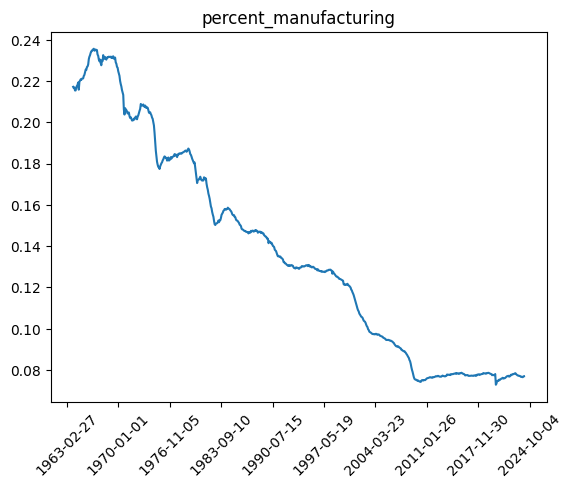

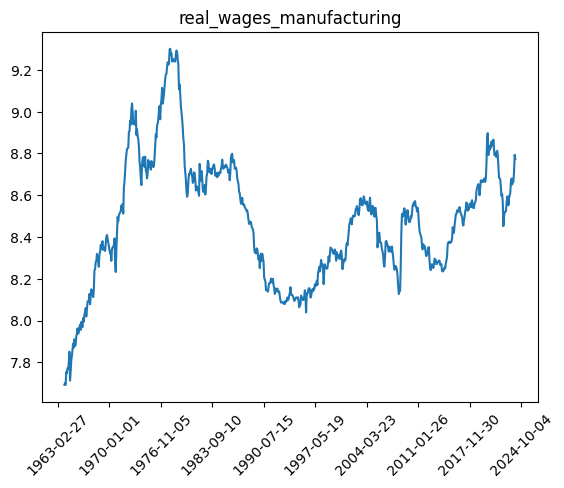

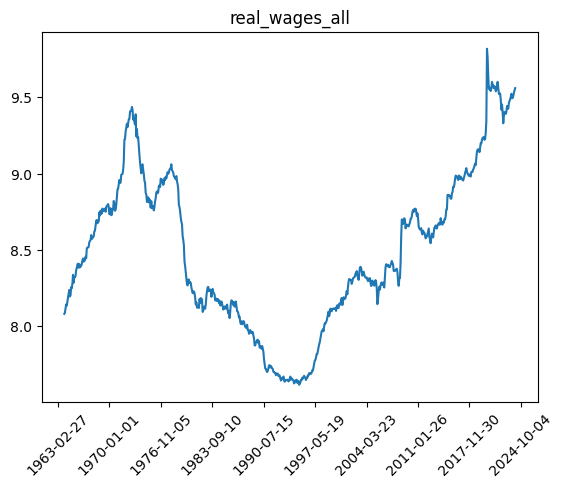

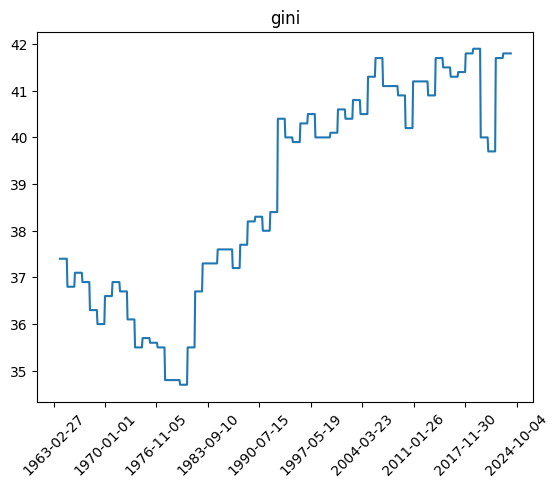

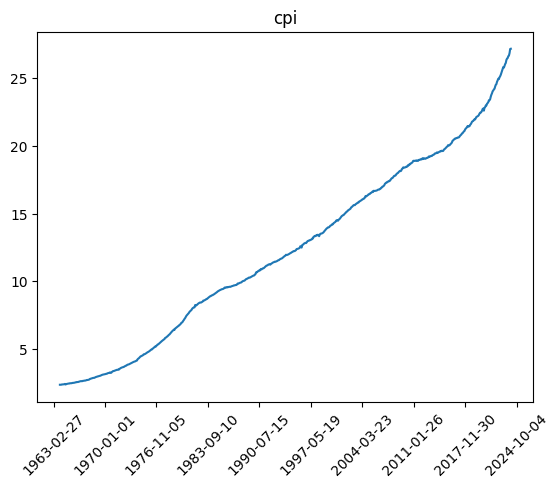

In [71]:
# Early visualizations
for label, content in data_combined.drop("observation_date",axis=1).items():
    years=data_combined["observation_date"]
    plt.plot(years, content)
    plt.title(f"{label}")
    plt.xticks(rotation=45)
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
    plt.show()

### Analyses


In [93]:
# Checking for stationarity in the data
def stationarity(dataset):
    for label, content in dataset.drop("observation_date",axis=1).items():
        ADF = adfuller(content, regression='ct')
        print(f"Stationarity testing for {label}:\n--------------------")
        print("DF-GLS statistic: %f" % ADF[0])
        print("DF-GLS p-value: %f" % ADF[1])

        # KPSS Test
        KPSS = kpss(content, regression='ct')
        print("KPSS test statistic: %f" % KPSS[0])
        print("KPSS p-value: %f" % KPSS[1])
        print("--------------------")

# Differencing the data
data_differenced = data_combined.diff().dropna()
stationarity(data_differenced)

Stationarity testing for percent_manufacturing:
--------------------
DF-GLS statistic: -8.792263
DF-GLS p-value: 0.000000
KPSS test statistic: 0.080311
KPSS p-value: 0.100000
--------------------
Stationarity testing for real_wages_manufacturing:
--------------------
DF-GLS statistic: -6.445318
DF-GLS p-value: 0.000000
KPSS test statistic: 0.204149
KPSS p-value: 0.014444
--------------------
Stationarity testing for real_wages_all:
--------------------
DF-GLS statistic: -4.610740
DF-GLS p-value: 0.000989
KPSS test statistic: 0.250300
KPSS p-value: 0.010000
--------------------
Stationarity testing for gini:
--------------------
DF-GLS statistic: -26.801851
DF-GLS p-value: 0.000000
KPSS test statistic: 0.077690
KPSS p-value: 0.100000
--------------------
Stationarity testing for cpi:
--------------------
DF-GLS statistic: -0.060434
DF-GLS p-value: 0.993567
KPSS test statistic: 0.353923
KPSS p-value: 0.010000
--------------------


C:\Users\yyork\AppData\Local\Temp\ipykernel_37244\2761193709.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  KPSS = kpss(content, regression='ct')
C:\Users\yyork\AppData\Local\Temp\ipykernel_37244\2761193709.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  KPSS = kpss(content, regression='ct')
C:\Users\yyork\AppData\Local\Temp\ipykernel_37244\2761193709.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  KPSS = kpss(content, regression='ct')
C:\Users\yyork\AppData\Local\Temp\ipykernel_37244\2761193709.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table

Break points at indices: [721]


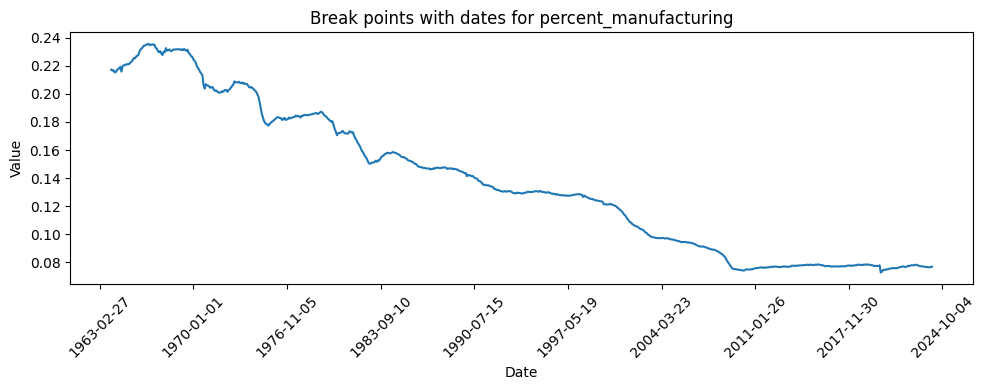

Break points at indices: [85, 285, 625, 721]


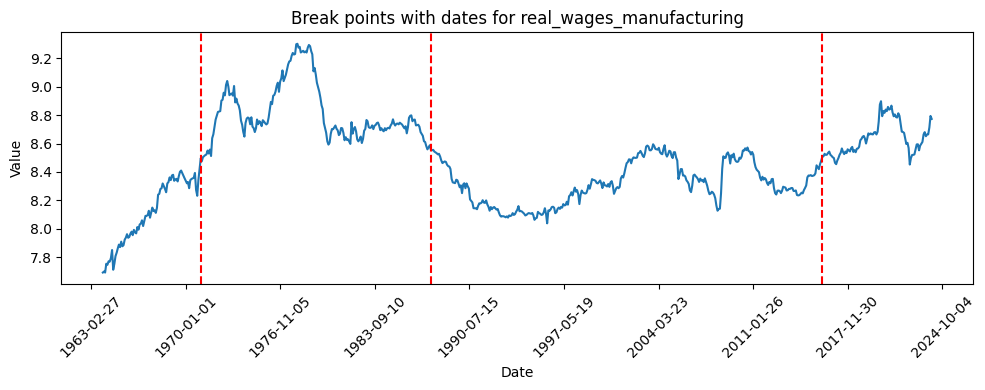

Break points at indices: [50, 190, 300, 415, 540, 660, 721]


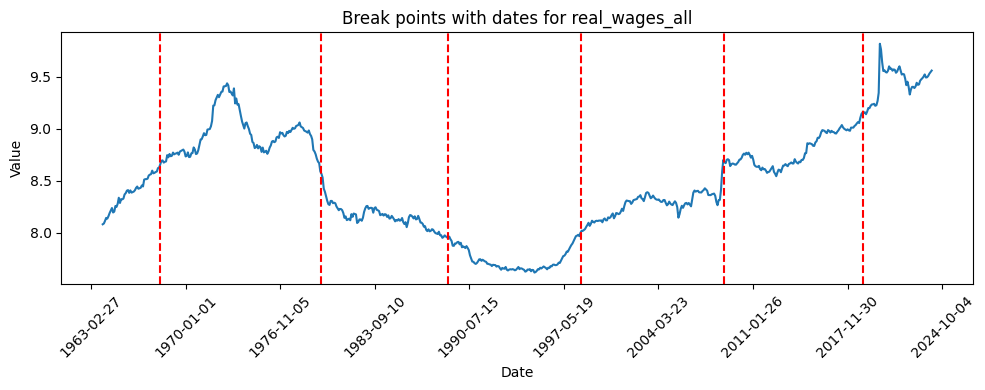

Break points at indices: [45, 120, 165, 215, 230, 300, 345, 445, 490, 600, 675, 695, 721]


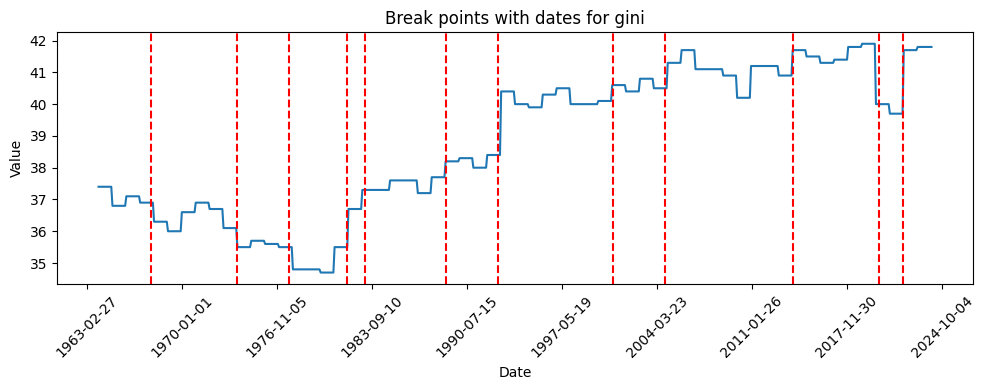

Break points at indices: [55, 95, 125, 155, 180, 200, 220, 250, 290, 320, 355, 390, 425, 455, 485, 520, 545, 590, 625, 650, 670, 690, 705, 721]


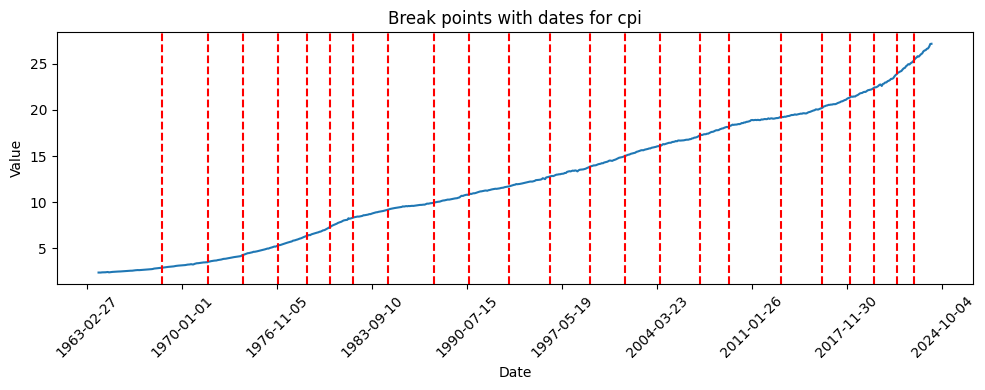

In [94]:
# Checking for structural breaks in the data
def break_points(dataset):
    for label, content in dataset.drop("observation_date",axis=1).items():
        years = data_combined["observation_date"]
        signal = content.values
        model = "l2"
        algo = rpt.Pelt(model=model).fit(signal)    
        breaks = algo.predict(pen=5)
        print("Break points at indices:", breaks)
        break_indices = breaks[:-1]  # Exclude the last index (end of series)
        date_labels = years.iloc[break_indices]

        plt.figure(figsize=(10, 4))
        plt.plot(years, content)
        for idx in break_indices:
            plt.axvline(x=years.iloc[idx], color='red', linestyle='--')
        plt.xticks(rotation=45)
        plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
        plt.xlabel("Date")
        plt.ylabel("Value")
        plt.title(f"Break points with dates for {label}")
        plt.tight_layout()
        plt.show()

break_points(data_combined)

Break points at indices: [10, 20, 30, 40, 62]


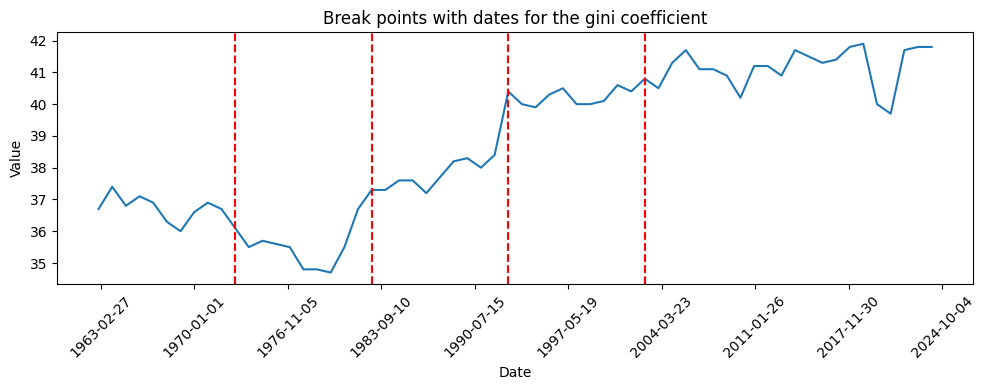

In [92]:
# Finding break points for the non-interpolated gini

years = gini["observation_date"]
signal = gini["SIPOVGINIUSA"].values
model = "l2"
algo = rpt.Pelt(model=model).fit(signal)    
breaks = algo.predict(pen=5)
print("Break points at indices:", breaks)
break_indices = breaks[:-1]  # Exclude the last index (end of series)
date_labels = years.iloc[break_indices]

plt.figure(figsize=(10, 4))
plt.plot(years, gini["SIPOVGINIUSA"])
for idx in break_indices:
    plt.axvline(x=years.iloc[idx], color='red', linestyle='--')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Break points with dates for the gini coefficient")
plt.tight_layout()
plt.show()

### Cross-variance and cointegration between wealth inequality and manufacturing

In [74]:
# Granger causality test
def granger(input):
    return(grangercausalitytests(input, 4))
    
granger(data_differenced[["gini","percent_manufacturing"]])
granger(data_differenced[["percent_manufacturing","real_wages_manufacturing"]])

# Vector autoregression
def granger_var(input):
    model = VAR(input)
    results = model.fit(maxlags=10, ic='aic')
    return(results.summary())

# granger_var(data_differenced[["SIPOVGINIUSA","percent_manufacturing"]])
def cointegration(input):
    score, pvalue, _ = coint(input[input.columns[0]], input[input.columns[1]])
    print(f"Cointegration test statistic: {score}")
    print(f"Cointegration p-value: {pvalue}")
    
cointegration(data_combined[["real_wages_manufacturing", "real_wages_all"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0586  , p=0.8088  , df_denom=716, df_num=1
ssr based chi2 test:   chi2=0.0588  , p=0.8084  , df=1
likelihood ratio test: chi2=0.0588  , p=0.8084  , df=1
parameter F test:         F=0.0586  , p=0.8088  , df_denom=716, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.0317  , p=0.1319  , df_denom=713, df_num=2
ssr based chi2 test:   chi2=4.0920  , p=0.1293  , df=2
likelihood ratio test: chi2=4.0804  , p=0.1300  , df=2
parameter F test:         F=2.0317  , p=0.1319  , df_denom=713, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.4291  , p=0.2330  , df_denom=710, df_num=3
ssr based chi2 test:   chi2=4.3294  , p=0.2280  , df=3
likelihood ratio test: chi2=4.3164  , p=0.2293  , df=3
parameter F test:         F=1.4291  , p=0.2330  , df_denom=710, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.1165  , p=0.3475  

In [107]:
# Segment-wise cointegration test based on breakpoints
all_wages_breaks = [0, 50, 195, 450, 620, 721]
manu_wages_breaks = [0, 85, 280, 721]
gini_breaks =  [0, 120, 240, 360, 480, 732]

results = []
for i in range(len(all_wages_breaks)-1):
    # Find overlap for this segment
    seg_start = max(all_wages_breaks[i], manu_wages_breaks[i] if i < len(manu_wages_breaks)-1 else manu_wages_breaks[-2])
    seg_end = min(all_wages_breaks[i+1], manu_wages_breaks[i+1] if i+1 < len(manu_wages_breaks) else manu_wages_breaks[-1])
    if seg_start >= seg_end:
        continue
    seg = data_combined.iloc[seg_start:seg_end]
    if len(seg) < 30:
        continue  # skip very short segments
    score, pvalue, _ = coint(seg["real_wages_manufacturing"], seg["real_wages_all"])
    results.append({
        "segment": (seg_start, seg_end),
        "n_obs": len(seg),
        "statistic": score,
        "pvalue": pvalue
    })

for r in results:
    print(f"Segment {r['segment'][0]}–{r['segment'][1]} (n={r['n_obs']}): stat={r['statistic']:.2f}, p={r['pvalue']:.3f}")

Segment 0–50 (n=50): stat=-4.50, p=0.001
Segment 85–195 (n=110): stat=-2.05, p=0.500
Segment 280–450 (n=170): stat=-2.09, p=0.481
Segment 450–620 (n=170): stat=-2.60, p=0.237
Segment 620–721 (n=101): stat=-1.58, p=0.731


In [108]:
# Segment-wise cointegration test: manufacturing wages vs. gini (using non-interpolated gini breakpoints)
gini_breaks_monthly = gini_breaks  # <-- Replace with your actual indices from previous cell

results_gini = []
for i in range(len(gini_breaks_monthly)-1):
    seg_start = gini_breaks_monthly[i]
    seg_end = gini_breaks_monthly[i+1]
    if seg_start >= seg_end:
        continue
    seg = data_combined.iloc[seg_start:seg_end]
    if len(seg) < 30:
        continue  # skip very short segments
    score, pvalue, _ = coint(seg["real_wages_manufacturing"], seg["gini"])
    results_gini.append({
        "segment": (seg_start, seg_end),
        "n_obs": len(seg),
        "statistic": score,
        "pvalue": pvalue
    })

for r in results_gini:
    print(f"Segment {r['segment'][0]}–{r['segment'][1]} (n={r['n_obs']}): stat={r['statistic']:.2f}, p={r['pvalue']:.3f}")

Segment 0–120 (n=120): stat=-1.40, p=0.796
Segment 120–240 (n=120): stat=-1.31, p=0.826
Segment 240–360 (n=120): stat=-1.48, p=0.768
Segment 360–480 (n=120): stat=-1.61, p=0.715
Segment 480–732 (n=241): stat=-0.92, p=0.916


In [98]:
# Find the index positions in monthly_gini for each non-interpolated Gini break date
# Example: gini_break_dates = [10, 20, 30, 40, 62] (indices in annual data)
# Get the actual dates of the breaks in the annual data
gini_break_indices_annual = [10, 20, 30, 40, 61]
gini_break_dates = gini.iloc[gini_break_indices_annual]["observation_date"].values
# Find the corresponding indices in monthly_gini
monthly_gini_break_indices = [monthly_gini.index[monthly_gini["observation_date"] == d][0] for d in gini_break_dates]
print("Break dates in annual Gini:", gini_break_dates)
print("Corresponding indices in monthly_gini:", monthly_gini_break_indices)

Break dates in annual Gini: ['1973-01-01T00:00:00.000000' '1983-01-01T00:00:00.000000'
 '1993-01-01T00:00:00.000000' '2003-01-01T00:00:00.000000'
 '2024-01-01T00:00:00.000000']
Corresponding indices in monthly_gini: [120, 240, 360, 480, 732]
